# Yale ED Triage Dataset — Data Profiling & Feasibility Analysis
**CariSurg MedPath Research Project — Week 5**
**Student:** Kaylah Leigertwood-Ollivierre

## Notebook Purpose

This notebook performs structured data profiling of the Yale Emergency Medicine
Machine Learning Consortium (EMMLC) admission prediction dataset
(`yaleemmlc_admissionprediction_triage.csv`).

The profiling addresses four questions that any clinical AI project must answer
before model development begins:

1. **What is the structure of the data?** — shape, column types, basic statistics
2. **How complete is the data?** — missing values per column, quantified as
   raw counts and percentages
3. **Are the data types consistent?** — columns that should be numeric but were
   read as text, or vice versa
4. **Are the vital signs plausible?** — outlier detection using the IQR method


---
**Dataset source:** Yale New Haven Health System Emergency Department  
**Outcome variable:** `disposition` — patient's final ED outcome  
**Primary triage variable:** `esi` — Emergency Severity Index (1–5)


In [ ]:
# Confirming Python version is greater than or equal to 3.10
import sys
print(sys.version)


3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 1 — Load Dataset

The dataset is loaded into `df_raw` — a name that signals this is the
unmodified original, before any cleaning or transformation. A copy used
for type corrections is kept separate so the raw state remains inspectable
throughout the notebook.

**Expected structure:** ~560,000 ED encounters × 230+ columns spanning
demographics, triage vital signs, and binary chief complaint indicators.



In [ ]:
# Dataset is directly loaded into Colab and displays the shape & column names
FILE_PATH = 'yaleemmlc_admissionprediction_triage.csv'
df_raw = pd.read_csv(FILE_PATH)

print(f"Dataset loaded successfully.")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumn groups:")
print(f"  Chief complaint (cc_*) columns : {sum(1 for c in df_raw.columns if c.startswith('cc_'))}")
print(f"  Vital sign columns              : {sum(1 for c in df_raw.columns if 'vital' in c)}")
print(f"  Demographic columns             : approx. 10")

df_raw.head(5)

Dataset loaded successfully.
Shape: 55,121 rows × 226 columns

Column groups:
  Chief complaint (cc_*) columns : 200
  Vital sign columns              : 7
  Demographic columns             : approx. 10


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,cc_breastpain,cc_breathingdifficulty,cc_breathingproblem,cc_burn,cc_cardiacarrest,cc_cellulitis,cc_chestpain,cc_chesttightness,cc_chills,cc_coldlikesymptoms,cc_confusion,cc_conjunctivitis,cc_constipation,cc_cough,cc_cyst,cc_decreasedbloodsugar-symptomatic,cc_dehydration,cc_dentalpain,cc_depression,cc_detoxevaluation,cc_diarrhea,cc_dizziness,cc_drug/alcoholassessment,cc_drugproblem,cc_dyspnea,cc_dysuria,cc_earpain,cc_earproblem,cc_edema,cc_elbowpain,cc_elevatedbloodsugar-nosymptoms,cc_elevatedbloodsugar-symptomatic,cc_emesis,cc_epigastricpain,cc_epistaxis,cc_exposuretostd,cc_extremitylaceration,cc_extremityweakness,cc_eyeinjury,cc_eyepain,cc_eyeproblem,cc_eyeredness,cc_facialinjury,cc_faciallaceration,cc_facialpain,cc_facialswelling,cc_fall,cc_fall>65,cc_fatigue,cc_femaleguproblem,cc_fever,cc_fever-75yearsorolder,cc_fever-9weeksto74years,cc_feverimmunocompromised,cc_fingerinjury,cc_fingerpain,cc_fingerswelling,cc_flankpain,cc_follow-upcellulitis,cc_footinjury,cc_footpain,cc_footswelling,cc_foreignbodyineye,cc_fulltrauma,cc_generalizedbodyaches,cc_gibleeding,cc_giproblem,cc_groinpain,cc_hallucinations,cc_handinjury,cc_handpain,cc_headache,cc_headache-newonsetornewsymptoms,cc_headache-recurrentorknowndxmigraines,cc_headachere-evaluation,cc_headinjury,cc_headlaceration,cc_hematuria,cc_hemoptysis,cc_hippain,cc_homicidal,cc_hyperglycemia,cc_hypertension,cc_hypotension,cc_influenza,cc_ingestion,cc_insectbite,cc_irregularheartbeat,cc_jawpain,cc_jointswelling,cc_kneeinjury,cc_kneepain,cc_laceration,cc_leginjury,cc_legpain,cc_legswelling,cc_lethargy,cc_lossofconsciousness,cc_maleguproblem,cc_mass,cc_medicalproblem,cc_medicalscreening,cc_medicationproblem,cc_medicationrefill,cc_migraine,cc_modifiedtrauma,cc_motorcyclecrash,cc_motorvehiclecrash,cc_multiplefalls,cc_nasalcongestion,cc_nausea,cc_nearsyncope,cc_neckpain,cc_neurologicproblem,cc_numbness,cc_oralswelling,cc_otalgia,cc_other,cc_overdose-accidental,cc_overdose-intentional,cc_pain,cc_palpitations,cc_panicattack,cc_pelvicpain,cc_poisoning,cc_post-opproblem,cc_psychiatricevaluation,cc_psychoticsymptoms,cc_rapidheartrate,cc_rash,cc_rectalbleeding,cc_rectalpain,cc_respiratorydistress,cc_ribinjury,cc_ribpain,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.00,87.00,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.00,155.00,75.00,17.00,98.00,0.00,97.80,87.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0

## Section 2 — Initial Structure

`.info()` reports the total number of entries, column names, non-null counts,
and inferred data types. This is the first check for type inconsistencies —
columns that should be numeric but appear as `object` (string) will be
flagged here and corrected in Section 4.


In [ ]:
print("=" * 65)
print("DATAFRAME INFO")
print("=" * 65)
df_raw.info(verbose=True, show_counts=True)


DATAFRAME INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55121 entries, 0 to 55120
Data columns (total 226 columns):
 #    Column                                   Non-Null Count  Dtype  
---   ------                                   --------------  -----  
 0    Unnamed: 0                               55121 non-null  int64  
 1    dep_name                                 55121 non-null  object 
 2    esi                                      55121 non-null  float64
 3    age                                      55121 non-null  float64
 4    gender                                   55121 non-null  object 
 5    ethnicity                                55121 non-null  object 
 6    race                                     55121 non-null  object 
 7    lang                                     55121 non-null  object 
 8    religion                                 55121 non-null  object 
 9    maritalstatus                            55121 non-null  object 
 10   employstatus     

## Section 3 — Descriptive Statistics

`.describe()` summarises the central tendency, spread, and range of all
numeric columns. For triage vital signs, physiologically implausible values
(e.g. heart rate = 0, SpO2 > 100, temperature < 30 °C) flag probable data
entry errors and will be explored further in the outlier section.

**Clinical reference ranges used for plausibility checks:**

| Vital | Normal adult range |
|---|---|
| Heart rate | 60–100 bpm |
| Systolic BP | 90–140 mmHg |
| Diastolic BP | 60–90 mmHg |
| Respiratory rate | 12–20 bpm |
| SpO2 | 95–100 % |
| Temperature | 36.1–37.2 °C |
| Blood glucose | 3.9–11.1 mmol/L |


In [ ]:
print("Descriptive statistics — numeric columns:")
display(df_raw.describe().round(2).T)

Descriptive statistics — numeric columns:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,55121.00,204574.02,120486.08,7.00,101645.00,202183.00,303501.00,433332.00
esi,55121.00,2.88,0.75,1.00,2.00,3.00,3.00,5.00
age,55121.00,55.32,19.54,18.00,40.00,55.00,70.00,107.00
triage_vital_hr,55121.00,86.45,16.96,32.00,74.00,85.00,97.00,221.00
triage_vital_sbp,55121.00,133.68,22.65,53.00,118.00,132.00,147.00,266.00
...,...,...,...,...,...,...,...,...
cc_woundcheck,55121.00,0.01,0.07,0.00,0.00,0.00,0.00,1.00
cc_woundinfection,55121.00,0.00,0.06,0.00,0.00,0.00,0.00,1.00
cc_woundre-evaluation,55121.00,0.00,0.04,0.00,0.00,0.00,0.00,1.00
cc_wristinjury,55121.00,0.00,0.02,0.00,0.00,0.00,0.00,1.00


## Section 4 — Data Type Audit

Several clinical variables are expected to be numeric but may have been
read as `object` (text) by pandas — commonly because of mixed-type entries
such as `"N/A"`, `"unknown"`, or blank strings in the raw CSV.

The cells below:
1. Identify any expected-numeric columns currently stored as `object`
2. Force conversion using `pd.to_numeric(..., errors='coerce')`, which
   replaces unconvertible values with `NaN` (making the problem visible
   rather than silently dropping rows)


In [ ]:
numeric_cols_expected = [
    "age", "esi",
    "triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp",
    "triage_vital_rr", "triage_vital_o2",
    "triage_vital_temp", "triage_glucose"
]

print("Expected-numeric columns — current dtype in df_raw:")
dtype_audit = pd.DataFrame({
    "Column": numeric_cols_expected,
    "Current dtype": [str(df_raw[c].dtype) if c in df_raw.columns else "NOT FOUND"
                      for c in numeric_cols_expected],
    "Type issue?": ["YES — stored as text" if str(df_raw[c].dtype) == "object" else "No"
                    if c in df_raw.columns else "Column absent"
                    for c in numeric_cols_expected]
})
display(dtype_audit)

Expected-numeric columns — current dtype in df_raw:


,Column,Current dtype,Type issue?
0,age,float64,No
1,esi,float64,No
2,triage_vital_hr,float64,No
3,triage_vital_sbp,float64,No
4,triage_vital_dbp,float64,No
5,triage_vital_rr,float64,No
6,triage_vital_o2,float64,No
7,triage_vital_temp,float64,No
8,triage_glucose,float64,No


In [ ]:
# Convert expected-numeric columns; non-numeric entries become NaN
for col in numeric_cols_expected:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

print("Conversion complete. Updated dtypes:")
print(df_raw[numeric_cols_expected].dtypes.to_string())
print("\nNote: df_raw has been updated in place. The CSV file is unchanged.")

Conversion complete. Updated dtypes:
age                  float64
esi                  float64
triage_vital_hr      float64
triage_vital_sbp     float64
triage_vital_dbp     float64
triage_vital_rr      float64
triage_vital_o2      float64
triage_vital_temp    float64
triage_glucose       float64

Note: df_raw has been updated in place. The CSV file is unchanged.


## Section 5 — Missing Values

Missing data is one of the most clinically significant quality concerns in
ED datasets. At Mercer General ED, documentation completeness is a known
issue — Egerton-Warburton et al. (2025) report absent clinical impressions
in up to 67% of low-acuity encounters. This section quantifies missingness
per column in two forms:

- **Raw count** — the number of rows where the value is absent
- **Percentage** — the proportion of all encounters missing that value

These figures are used directly in the Feasibility Memo (Quality Concern 1).

In [ ]:
missing_counts = df_raw.isnull().sum()
missing_pct    = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing (%)":   missing_pct
})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(
    "Missing (%)", ascending=False
)

print(f"Columns with any missing values: {len(missing_df)} of {df_raw.shape[1]} total")
print(f"Overall dataset missingness    : {(df_raw.isnull().sum().sum() / df_raw.size * 100):.1f}%")
print()
display(missing_df)

Columns with any missing values: 0 of 226 total
Overall dataset missingness    : 0.0%



,Missing Count,Missing (%)


## Section 6 — Missingness Visualisation

Two complementary visualisations are produced and saved to `/docs`:

1. **Missingness matrix** (`missingno.matrix`) — shows the pattern of
   missing data across all encounters. White gaps indicate missing values;
   dark bands indicate complete data. Useful for spotting whether missingness
   is random or systematic (e.g., one variable always missing alongside another).

2. **Per-column bar chart** — ranks columns by missingness percentage so
   the reader can identify the highest-missing variables at a glance.

Both files are saved as `.png` and must be committed to `/docs`.

In [ ]:
cols_with_missing = missing_df.index.tolist()

if len(cols_with_missing) == 0:
    print("No missing values found. Missingness visualisation skipped.")
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    msno.matrix(
        df_raw[cols_with_missing],
        ax=ax,
        sparkline=False,
        color=(0.3, 0.4, 0.6)
    )
    ax.set_title(
        "Figure 1a — Missingness Matrix\n"
        "Yale Emergency Department Triage Dataset\n"
        "(White = missing | Dark = present)",
        fontsize=12, fontweight='bold', pad=12
    )
    plt.tight_layout()
    plt.savefig("fig1a_missingness_matrix.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure 1a saved — commit to /docs as fig1a_missingness_matrix.png")

No missing values found. Missingness visualisation skipped.


In [ ]:
if len(missing_df) == 0:
    print("No missing values — bar chart skipped.")
else:
    top_missing = missing_df.head(20).copy()
    top_missing = top_missing[
        top_missing["Missing (%)"].notna() &
        np.isfinite(top_missing["Missing (%)"])
    ]

    if len(top_missing) > 0:
        fig, ax = plt.subplots(figsize=(12, 6))
        bars = ax.barh(
            top_missing.index[::-1],
            top_missing["Missing (%)"][::-1],
            color=sns.color_palette("Reds_r", len(top_missing))
        )
        ax.set_xlabel("Percentage Missing (%)", fontsize=12)
        ax.set_title(
            "Figure 1b — Top 20 Variables with Missing Data\n"
            "Yale Emergency Department Triage Dataset",
            fontsize=12, fontweight='bold'
        )
        max_pct = top_missing["Missing (%)"].max()
        for bar, pct in zip(bars, top_missing["Missing (%)"][::-1]):
            ax.text(
                bar.get_width() + max_pct * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va='center', fontsize=9
            )
        ax.set_xlim(0, max_pct + max_pct * 0.18)
        plt.tight_layout()
        plt.savefig("fig1b_missingness_barchart.png", dpi=150, bbox_inches='tight')
        plt.show()
        print("Figure 1b saved — commit to /docs as fig1b_missingness_barchart.png")

No missing values — bar chart skipped.


## Section 7 — Outlier Detection

Vital signs are checked for physiologically implausible values using the
**IQR method**: any observation below Q1 − 1.5×IQR or above Q3 + 1.5×IQR
is flagged as an outlier.

**Clinical interpretation:**
- Some outliers represent genuinely critically ill patients (e.g. HR 180 bpm
  in SVT, glucose 40 mmol/L in diabetic ketoacidosis). These must be
  **retained** — they are exactly the population where accurate triage
  prediction matters most.
- Some outliers represent recording errors (e.g. HR = 0, SpO2 = 110%).
  These must be **removed** — ideally after clinical review rather than
  automatic deletion.

In [ ]:
vitals = [c for c in numeric_cols_expected if c in df_raw.columns and c != "esi"]

vital_labels = {
    "age":               "Age (years)",
    "triage_vital_hr":   "Heart Rate (bpm)",
    "triage_vital_sbp":  "Systolic BP (mmHg)",
    "triage_vital_dbp":  "Diastolic BP (mmHg)",
    "triage_vital_rr":   "Respiratory Rate (bpm)",
    "triage_vital_o2":   "SpO2 (%)",
    "triage_vital_temp": "Temperature (°C)",
    "triage_glucose":    "Blood Glucose (mmol/L)"
}

outlier_rows = []
for col in vitals:
    data = df_raw[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    outlier_rows.append({
        "Variable":        vital_labels.get(col, col),
        "Q1":              round(Q1, 1),
        "Median":          round(data.median(), 1),
        "Q3":              round(Q3, 1),
        "Lower fence":     round(lower, 1),
        "Upper fence":     round(upper, 1),
        "Outlier count":   int(n_out),
        "Outlier (%)":     round(n_out / len(data) * 100, 1)
    })

outlier_df = pd.DataFrame(outlier_rows)
print("Outlier Summary — IQR Method:")
display(outlier_df)

Outlier Summary — IQR Method:


,Variable,Q1,Median,Q3,Lower fence,Upper fence,Outlier count,Outlier (%)
0,Age (years),40.00,55.00,70.00,-5.00,115.00,0,0.00
1,Heart Rate (bpm),74.00,85.00,97.00,39.50,131.50,578,1.00
2,Systolic BP (mmHg),118.00,132.00,147.00,74.50,190.50,1028,1.90
3,Diastolic BP (mmHg),70.00,79.00,89.00,41.50,117.50,726,1.30
4,Respiratory Rate (bpm),16.00,18.00,18.00,13.00,21.00,2366,4.30
5,SpO2 (%),96.00,98.00,98.00,93.00,101.00,1505,2.70
6,Temperature (°C),97.70,98.00,98.40,96.60,99.50,3554,6.40
7,Blood Glucose (mmol/L),93.00,107.00,134.00,31.50,195.50,5673,10.30


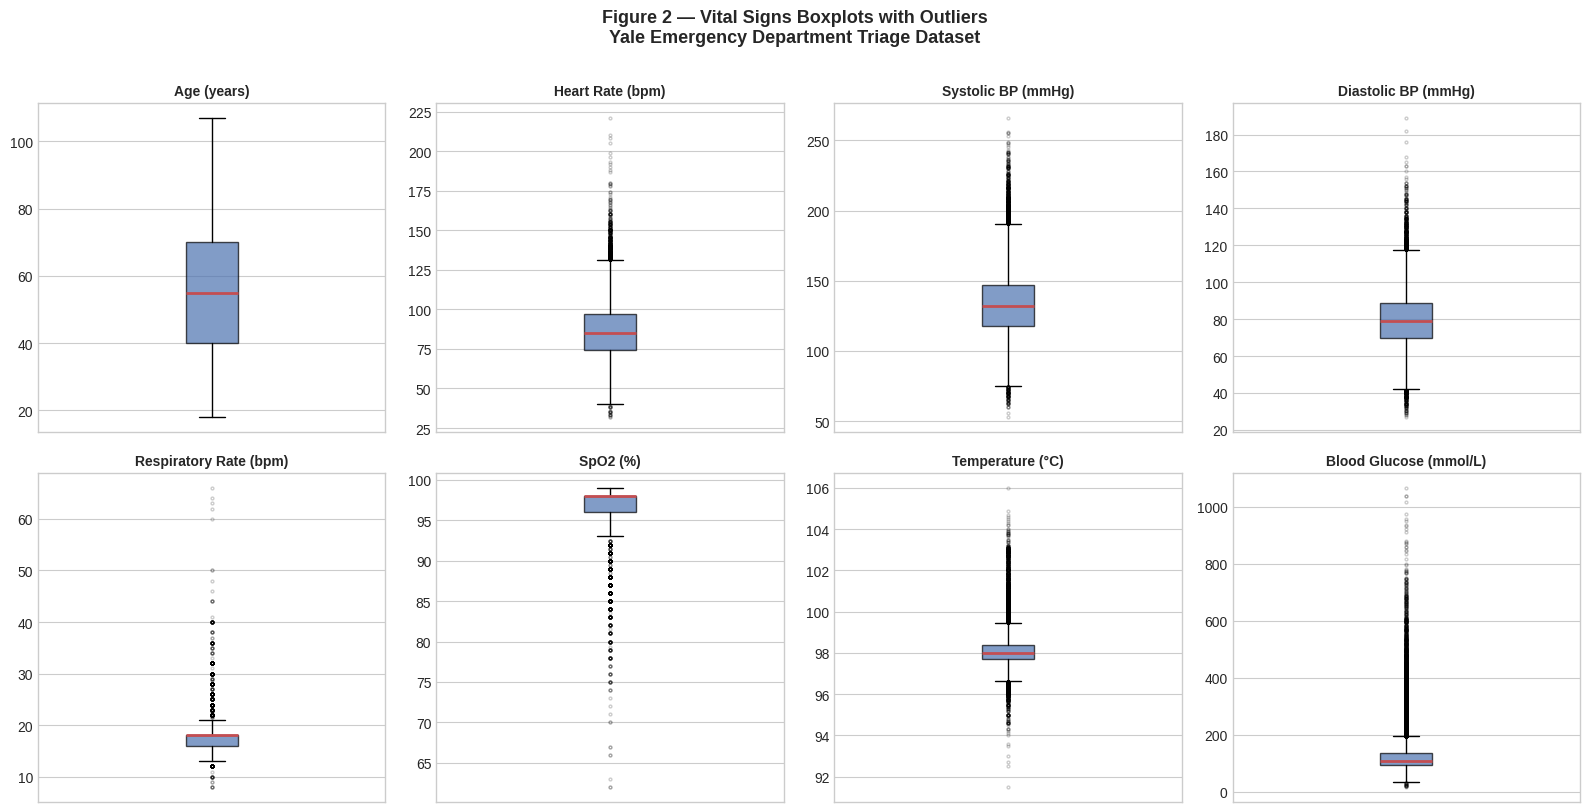

Figure 2 saved.


In [ ]:
n = len(vitals)
cols_per_row = 4
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(vitals):
    data = df_raw[col].dropna()
    axes[i].boxplot(
        data, vert=True, patch_artist=True,
        boxprops=dict(facecolor='#4C72B0', alpha=0.7),
        medianprops=dict(color='#C44E52', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.2, color='grey')
    )
    axes[i].set_title(vital_labels.get(col, col), fontsize=10, fontweight='bold')
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Figure 2 — Vital Signs Boxplots with Outliers\n"
    "Yale Emergency Department Triage Dataset",
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig("fig2_vitals_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

## Section 8 — ESI and Disposition Distributions

These two distributions answer the most operationally important questions
about the dataset:

- **ESI distribution** — what is the acuity mix of the training cohort?
  A dataset heavily skewed toward ESI 4–5 (non-urgent) will produce a model
  with limited performance on high-acuity presentations, which are
  disproportionately important for patient safety.

- **Disposition distribution** — is the outcome variable balanced? A dataset
  where 95% of patients are discharged and 5% admitted produces a model that
  achieves high apparent accuracy by predicting discharge for everyone —
  without learning anything clinically useful. Class imbalance handling
  (e.g. SMOTE, class weighting) may be required.

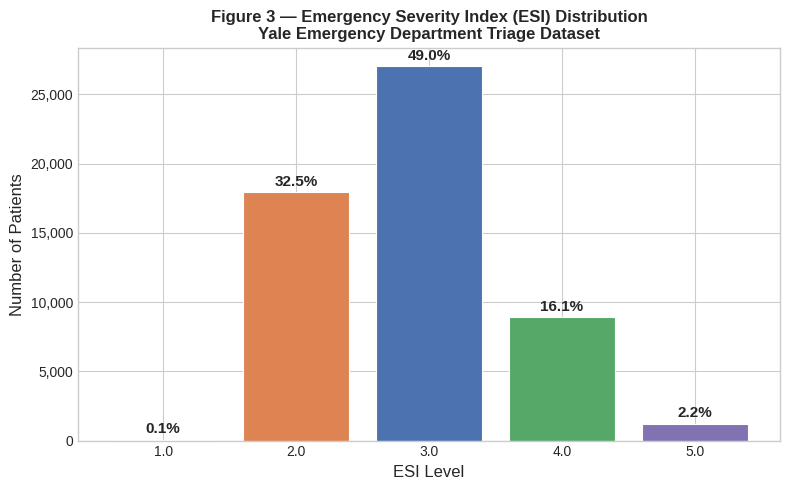

Figure 3 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
esi_counts = df_raw['esi'].value_counts().sort_index()
esi_pct    = (esi_counts / esi_counts.sum() * 100).round(1)
colors = ['#C44E52', '#DD8452', '#4C72B0', '#55A868', '#8172B2']
bars = ax.bar(
    esi_counts.index.astype(str), esi_counts.values,
    color=colors[:len(esi_counts)], edgecolor='white', linewidth=0.8
)
for bar, pct in zip(bars, esi_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + esi_counts.max() * 0.01,
        f"{pct:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_xlabel("ESI Level", fontsize=12)
ax.set_ylabel("Number of Patients", fontsize=12)
ax.set_title(
    "Figure 3 — Emergency Severity Index (ESI) Distribution\n"
    "Yale Emergency Department Triage Dataset",
    fontsize=12, fontweight='bold'
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
esi_desc = {
    "1": "Immediate (life-threatening)",
    "2": "Emergent (high risk)",
    "3": "Urgent (multiple resources)",
    "4": "Less urgent (one resource)",
    "5": "Non-urgent"
}
legend_lines = [f"ESI {k}: {v}" for k, v in esi_desc.items()
                if k in esi_counts.index.astype(str).tolist()]
ax.text(
    0.98, 0.95, "\n".join(legend_lines),
    transform=ax.transAxes, fontsize=8,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.4)
)
plt.tight_layout()
plt.savefig("fig3_esi_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

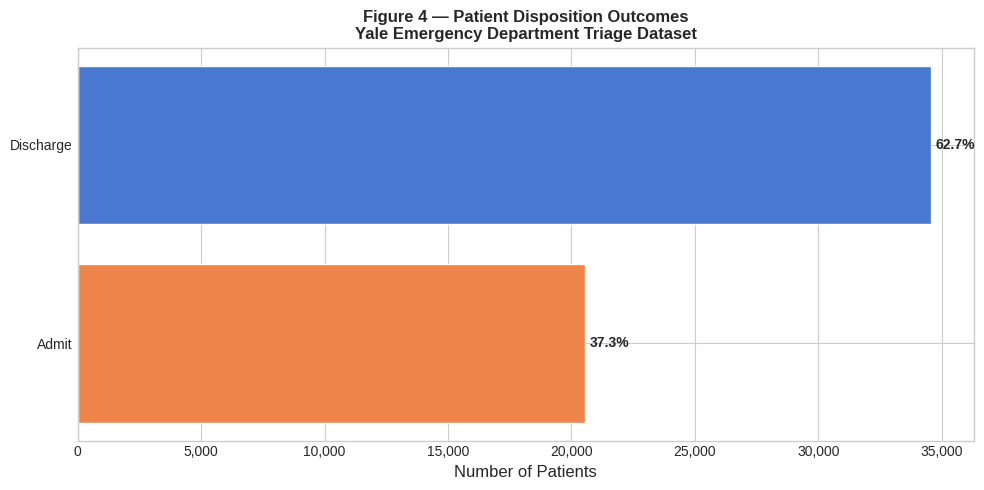

Figure 4 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
disp_counts = df_raw['disposition'].value_counts()
disp_pct    = (disp_counts / disp_counts.sum() * 100).round(1)
palette = sns.color_palette("muted", len(disp_counts))
bars = ax.barh(
    disp_counts.index[::-1], disp_counts.values[::-1],
    color=palette[::-1], edgecolor='white'
)
for bar, pct in zip(bars, disp_pct.values[::-1]):
    ax.text(
        bar.get_width() + disp_counts.max() * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%", va='center', fontsize=10, fontweight='bold'
    )
ax.set_xlabel("Number of Patients", fontsize=12)
ax.set_title(
    "Figure 4 — Patient Disposition Outcomes\n"
    "Yale Emergency Department Triage Dataset",
    fontsize=12, fontweight='bold'
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("fig4_disposition.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")

## Section 9 — Demographic Distribution

The racial and ethnic composition of the training dataset is directly relevant
to the equity dimension of this project. A model trained on a population that
does not represent the target deployment population (Afro-Caribbean and
Indo-Caribbean patients at Mercer General ED) risks systematically
underperforming for demographic subgroups that are sparse or absent in the
training data — a risk documented in the project's risk register (Risk 7 and
Risk 8) and in the literature (Huang et al., 2022; Teeple et al., 2023).

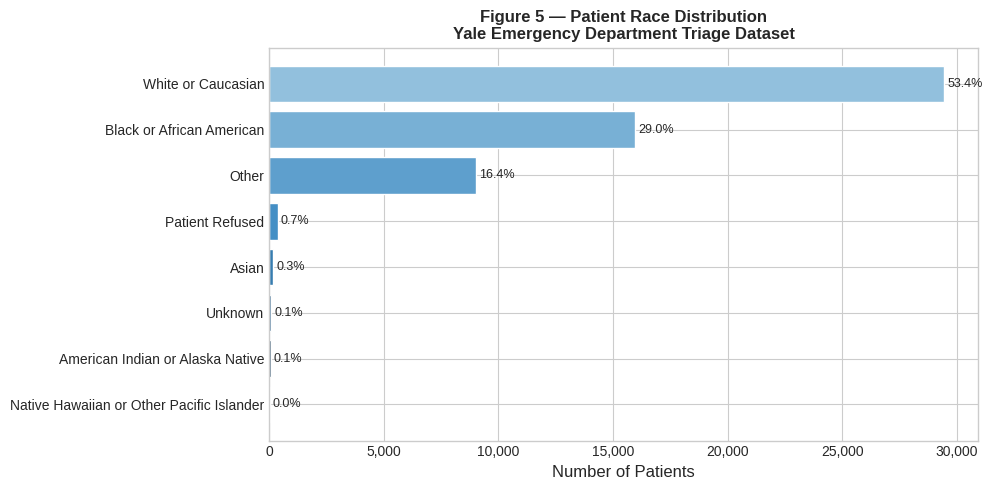

Figure 5 saved.


In [ ]:
if 'race' in df_raw.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    race_counts = df_raw['race'].value_counts().head(10)
    race_pct    = (race_counts / len(df_raw) * 100).round(1)
    bars = ax.barh(
        race_counts.index[::-1], race_counts.values[::-1],
        color=sns.color_palette("Blues_d", len(race_counts))[::-1],
        edgecolor='white'
    )
    for bar, pct in zip(bars, race_pct.values[::-1]):
        ax.text(
            bar.get_width() + race_counts.max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va='center', fontsize=9
        )
    ax.set_xlabel("Number of Patients", fontsize=12)
    ax.set_title(
        "Figure 5 — Patient Race Distribution\n"
        "Yale Emergency Department Triage Dataset",
        fontsize=12, fontweight='bold'
    )
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    plt.tight_layout()
    plt.savefig("fig5_race_distribution.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure 5 saved.")
else:
    print("'race' column not found in df_raw.")